# Evaluate Neural Networks

**Goal:** Understand how to measure and visualize the performance of a trained neural network.


After training, we need to check how well the neural network performs.  
Evaluation tells us if the model is learning correctly or just memorizing.

---

## Common Evaluation Metrics
- **Loss** → How wrong the model is.
- **Accuracy** → How often predictions are correct.
- **Confusion Matrix** → Shows correct vs incorrect predictions for each class.

---

## Layman Explanation
Think of a student after practice:
- **Loss** = number of mistakes made in homework.
- **Accuracy** = percentage of correct answers in the exam.
- **Confusion Matrix** = detailed report card showing which subjects the student did well in and where they got confused.


Test Loss: 0.916271984577179
Test Accuracy: 0.6333333253860474


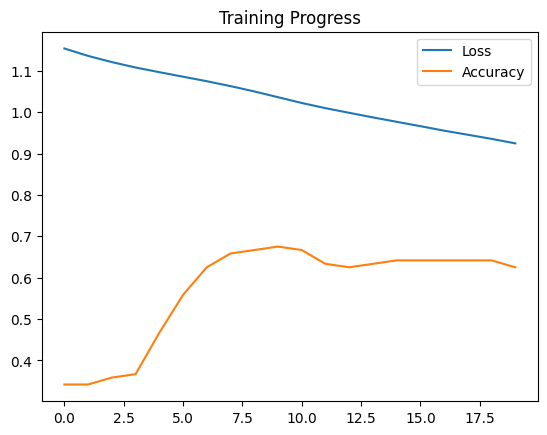

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


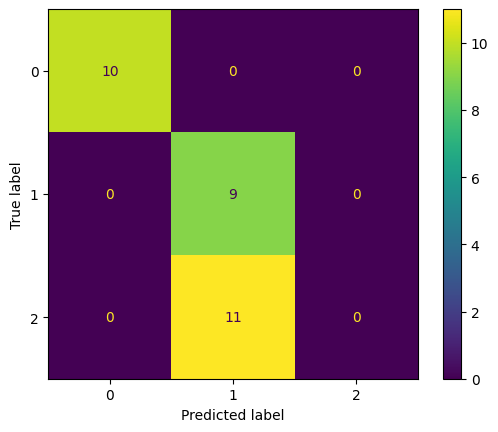

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
model = Sequential([
    Input(shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=8, verbose=0)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Plot loss and accuracy curves
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.legend()
plt.title("Training Progress")
plt.show()

# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
ConfusionMatrixDisplay(cm).plot()
plt.show()


- We trained a model on the Iris dataset.
- Checked **loss** (mistakes) and **accuracy** (correct answers).
- Plotted curves to see improvement over time.
- Built a confusion matrix to see which flower types were predicted correctly or wrongly.

Layman:
It’s like checking a student’s progress:
- Loss = number of mistakes in homework.
- Accuracy = exam score.
- Curves = progress chart over practice sessions.
- Confusion matrix = detailed report card showing strengths and weaknesses.
